Note: you may need to restart the kernel to use updated packages.


d:\AgenticBlogger\.venv\Scripts\python.exe: No module named uv


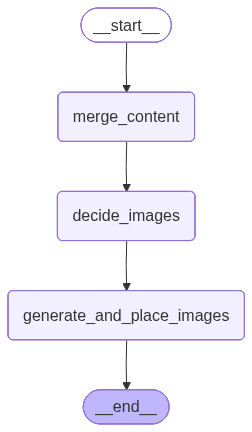

In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables.graph import MermaidDrawMethod
from typing import TypedDict, List, Annotated, Optional
import operator
import nest_asyncio

# ----------------------
# STATE DEFINITION
# ----------------------
class State(TypedDict):
    topic: str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[str]
    plan: Optional[str]

    sections: Annotated[List[tuple[int, str]], operator.add]
    merged_md: str
    md_with_placeholders: str
    image_specs: List[dict]
    final: str
    status: str

    feedback: Optional[str]
    notion_url: str


# ----------------------
# STUB NODE FUNCTIONS
# ----------------------

def router_node(state: State) -> State:
    return state


def route_next(state: State):
    # return either "research" or "orchestrator"
    return "orchestrator"


def research_node(state: State) -> State:
    return state


def orchestrator(state: State) -> State:
    return state


def worker_node(state: State) -> State:
    return state


def human_review_node(state: State) -> State:
    return state


def route_after_review(state: State):
    # return either "orchestrator" or "worker"
    return "worker"


# ---- Reducer Subgraph ----

def merge_content(state: State) -> State:
    return state


def decide_images(state: State) -> State:
    return state


def generate_and_place_images(state: State) -> State:
    return state


# ----------------------
# BUILD REDUCER SUBGRAPH
# ----------------------
reducer_graph = StateGraph(State)

reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)

reducer_graph.add_edge(START, "merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge("decide_images", "generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images", END)

reducer_subgraph = reducer_graph.compile()

reducer_subgraph


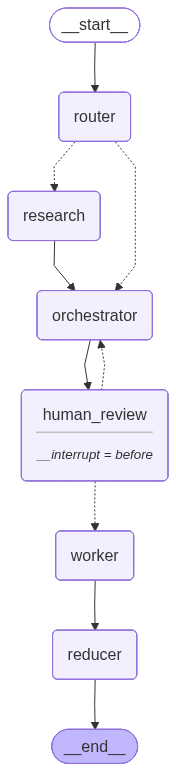

In [9]:
# ----------------------
# MAIN GRAPH
# ----------------------
checkpointer = InMemorySaver()

g = StateGraph(State)

g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_subgraph)
g.add_node("human_review", human_review_node)

g.add_edge(START, "router")

g.add_conditional_edges(
    "router",
    route_next,
    {
        "research": "research",
        "orchestrator": "orchestrator"
    }
)

g.add_edge("research", "orchestrator")
g.add_edge("orchestrator", "human_review")

g.add_conditional_edges(
    "human_review",
    route_after_review,
    ["orchestrator", "worker"]
)

g.add_edge("worker", "reducer")
g.add_edge("reducer", END)



app = g.compile(
    checkpointer=checkpointer,
    interrupt_before=["human_review"]
)

app